In [8]:
!pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings; warnings.filterwarnings('ignore')

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.0 MB 5.1 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 5.9 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 5.9 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 5.9 MB/s eta 0:00:02
   --------- ------------------------------ 1.8/8.0 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 1.8/8.0 MB 1.9 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.0 MB 1.5 MB/s eta 0:00:05
   ----------- ---------------------------- 2.4/8.0 MB 1.4 MB/s eta 0:00:05
   ------------- -------------------------- 2.6/8.0 MB 1.4 MB/s eta 0:00:04
   -------------- ------------------------- 2.9/8.0 MB 1.4 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.0 MB 1.3 MB/s eta 0:00:04
   ----------------- ---------------------- 3.4/8.0 MB 1.3 MB/s eta 0:00:04
   ----------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
df = pd.read_csv("D:\Downloads\Autism_data - Autism_data.csv.csv")
print("Shape:", df.shape)
df.head()


print(df.dtypes)
print("Missing:", df.isnull().sum()[df.isnull().sum() > 0])


df.nunique()

Shape: (800, 22)
ID                   int64
A1_Score             int64
A2_Score             int64
A3_Score             int64
A4_Score             int64
A5_Score             int64
A6_Score             int64
A7_Score             int64
A8_Score             int64
A9_Score             int64
A10_Score            int64
age                float64
gender              object
ethnicity           object
jaundice            object
austim              object
contry_of_res       object
used_app_before     object
result             float64
age_desc            object
relation            object
Class/ASD            int64
dtype: object
Missing: Series([], dtype: int64)


ID                 800
A1_Score             2
A2_Score             2
A3_Score             2
A4_Score             2
A5_Score             2
A6_Score             2
A7_Score             2
A8_Score             2
A9_Score             2
A10_Score            2
age                800
gender               2
ethnicity           12
jaundice             2
austim               2
contry_of_res       56
used_app_before      2
result             800
age_desc             1
relation             6
Class/ASD            2
dtype: int64

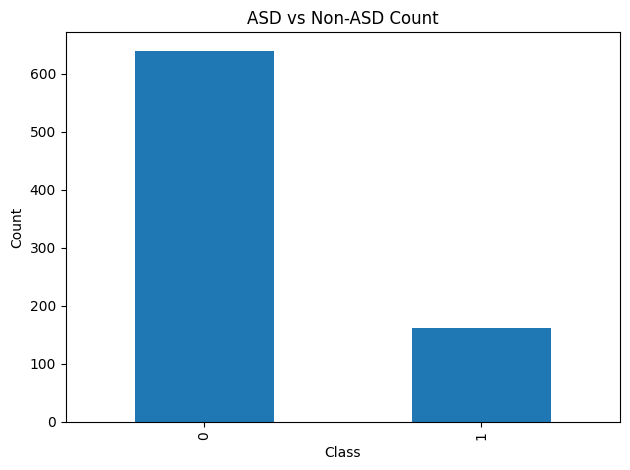

Class/ASD
0    639
1    161
Name: count, dtype: int64


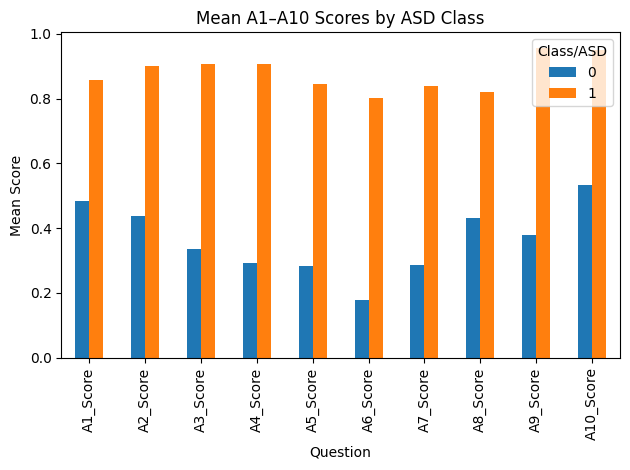

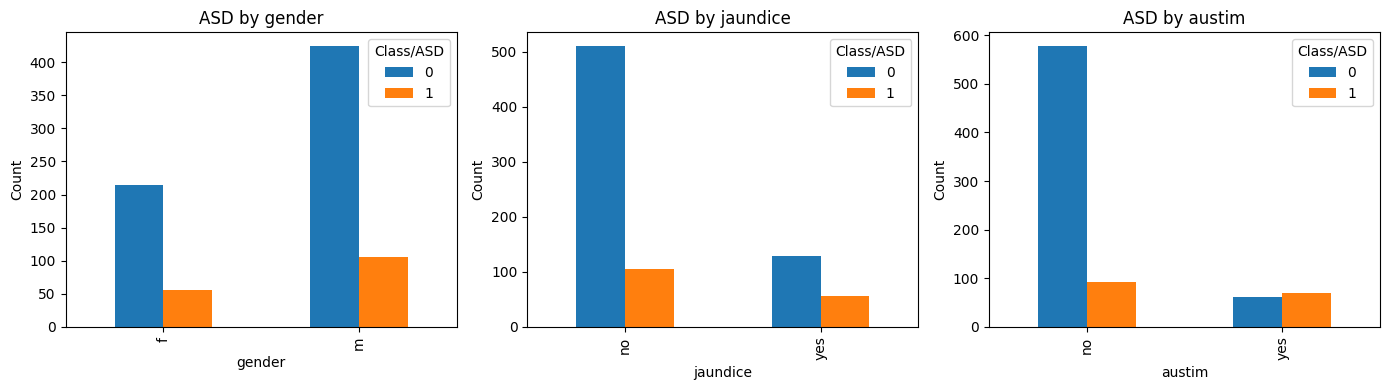

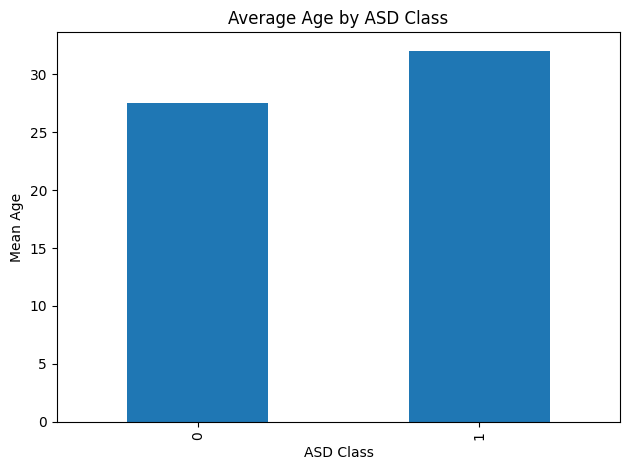

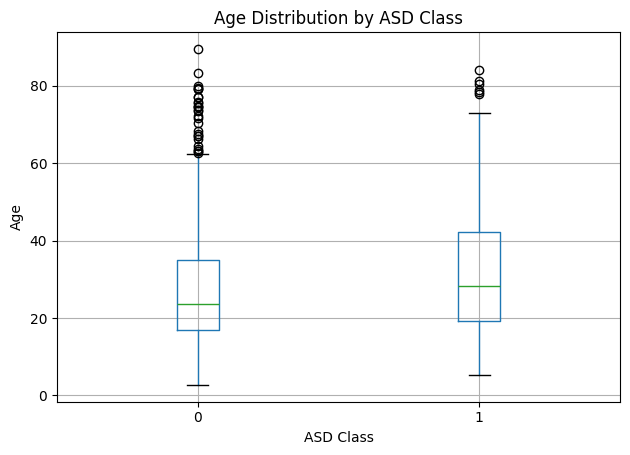

In [ ]:
TARGET = 'Class/ASD'

df[TARGET].value_counts().plot(kind='bar')
plt.title("ASD vs Non-ASD Count")
plt.xlabel("Class"); plt.ylabel("Count")
plt.tight_layout(); plt.show()
print(df[TARGET].value_counts())

A_COLS = [f'A{i}_Score' for i in range(1, 11)]
df.groupby(TARGET)[A_COLS].mean().T.plot(kind='bar')
plt.title("Mean A1–A10 Scores by ASD Class")
plt.xlabel("Question"); plt.ylabel("Mean Score")
plt.tight_layout(); plt.show()

autism_col = 'austim' if 'austim' in df.columns else 'autism'

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['gender', 'jaundice', autism_col]):
    pd.crosstab(df[col], df[TARGET]).plot(kind='bar', ax=ax)
    ax.set_title(f'ASD by {col}')
    ax.set_xlabel(col); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

df['age'] = pd.to_numeric(df['age'], errors='coerce')
age_groups = df.groupby(TARGET)['age'].mean()
age_groups.plot(kind='bar')
plt.title("Average Age by ASD Class")
plt.xlabel("ASD Class"); plt.ylabel("Mean Age")
plt.tight_layout(); plt.show()


df.boxplot(column='age', by=TARGET)
plt.title("Age Distribution by ASD Class")
plt.suptitle("")
plt.xlabel("ASD Class"); plt.ylabel("Age")
plt.tight_layout(); plt.show()


In [ ]:
#phase3
df.drop(columns=['ID'], inplace=True, errors='ignore')
print("Shape after drop:", df.shape)



if df['Class/ASD'].dtype == 'object':
    df['Class/ASD'] = (df['Class/ASD'].str.strip().str.upper() == 'YES').astype(int)
else:
    df['Class/ASD'] = df['Class/ASD'].astype(int)
print(df['Class/ASD'].value_counts())


cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape after encoding:", df.shape)


X = df.drop(columns=['Class/ASD'])
y = df['Class/ASD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)


scaler = StandardScaler()
X_train[['age']] = scaler.fit_transform(X_train[['age']])
X_test[['age']]  = scaler.transform(X_test[['age']])


Shape after drop: (800, 88)
Class/ASD
0    639
1    161
Name: count, dtype: int64
Shape after encoding: (800, 88)
Train: (640, 87) | Test: (160, 87)


In [23]:
#phase4
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression:")
print(classification_report(y_test, lr.predict(X_test)))


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest:")
print(classification_report(y_test, rf.predict(X_test)))


from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

dt = DecisionTreeClassifier(random_state=42)
knn = KNeighborsClassifier()
svm = SVC()

for name, model in [('Decision Tree', dt), ('KNN', knn), ('SVM', svm)]:
    model.fit(X_train, y_train)
    print(f"{name}:")
    print(classification_report(y_test, model.predict(X_test)))

Logistic Regression:
              precision    recall  f1-score   support

           0       0.89      0.94      0.92       124
           1       0.76      0.61      0.68        36

    accuracy                           0.87       160
   macro avg       0.83      0.78      0.80       160
weighted avg       0.86      0.87      0.86       160

Random Forest:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       124
           1       0.73      0.61      0.67        36

    accuracy                           0.86       160
   macro avg       0.81      0.77      0.79       160
weighted avg       0.86      0.86      0.86       160

Decision Tree:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       124
           1       0.61      0.61      0.61        36

    accuracy                           0.82       160
   macro avg       0.75      0.75      0.75       160
weighted avg       0.82

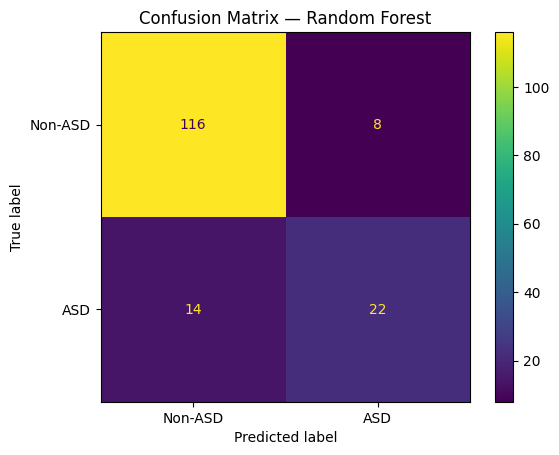

              precision    recall  f1-score   support

     Non-ASD       0.89      0.94      0.91       124
         ASD       0.73      0.61      0.67        36

    accuracy                           0.86       160
   macro avg       0.81      0.77      0.79       160
weighted avg       0.86      0.86      0.86       160



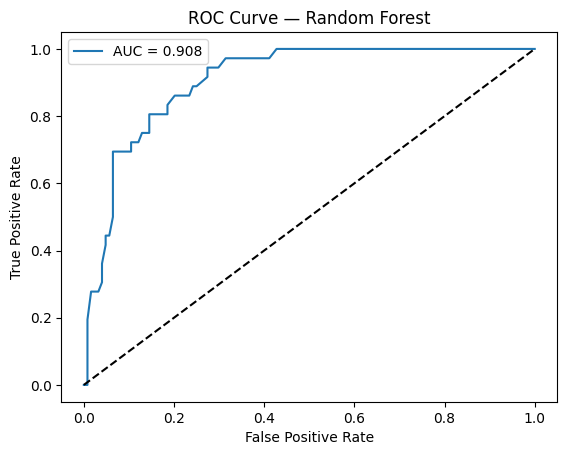

In [24]:
#phase5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=['Non-ASD', 'ASD']).plot()
plt.title("Confusion Matrix — Random Forest")
plt.show()

from sklearn.metrics import classification_report

print(classification_report(y_test, rf.predict(X_test), target_names=['Non-ASD', 'ASD']))

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve — Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [30]:
#phase6
#Tunable Hyperparameters ───
# Logistic Regression : C, penalty
# Decision Tree       : max_depth, min_samples_split, min_samples_leaf, criterion
# Random Forest       : n_estimators, max_depth, min_samples_split, max_features
# SVM                 : C, kernel, gamma
# KNN                 : n_neighbors, weights, metric

#Random Forest
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(RandomForestClassifier(random_state=42),
                    params, cv=5, scoring='recall')
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
rf_tuned = grid.best_estimator_

#fine tuning
from sklearn.metrics import classification_report, roc_auc_score

for name, model in [('RF Baseline', rf), ('RF Tuned', rf_tuned)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    rep = classification_report(y_test, y_pred, output_dict=True)['1']
    print(f"{name}")
    print(f"  Recall   : {rep['recall']:.3f}")
    print(f"  Precision: {rep['precision']:.3f}")
    print(f"  F1-Score : {rep['f1-score']:.3f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.3f}")
    print()

Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
RF Baseline
  Recall   : 0.611
  Precision: 0.733
  F1-Score : 0.667
  ROC-AUC  : 0.908

RF Tuned
  Recall   : 0.583
  Precision: 0.750
  F1-Score : 0.656
  ROC-AUC  : 0.920



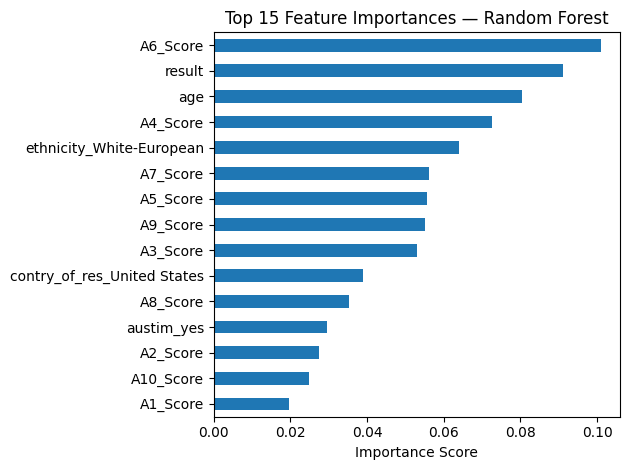

A6_Score                       0.100917
result                         0.091122
age                            0.080481
A4_Score                       0.072603
ethnicity_White-European       0.064057
A7_Score                       0.056148
A5_Score                       0.055688
A9_Score                       0.055066
A3_Score                       0.053064
contry_of_res_United States    0.038809
dtype: float64
Screening Questions Ranked by Importance:
A6_Score     0.100917
A4_Score     0.072603
A7_Score     0.056148
A5_Score     0.055688
A9_Score     0.055066
A3_Score     0.053064
A8_Score     0.035388
A2_Score     0.027488
A10_Score    0.024955
A1_Score     0.019731
dtype: float64


In [29]:
#phase7
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns)
importances.nlargest(15).sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importances — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print(importances.nlargest(10))

screening_importance = importances[[c for c in importances.index if 'Score' in c]]
print("Screening Questions Ranked by Importance:")
print(screening_importance.sort_values(ascending=False))